# L2 · 原创行为因子：52周高点锚定 · Research Notebook

> **研究问题**：美股经典的「52周高点」异象（George & Hwang 2004）在
> 散户主导、动量失效的 A 股是否成立？它是不是只是动量/反转的伪装？

这份 notebook 的看点不是"找到一个强因子"，而是一条**证伪自己**的递进推理：
朴素检验看似无效 → 发现它被反转掩盖 → 正交化后证明它独立有效 → 诚实承认它是二阶。

In [1]:
import sys, os
cwd = os.getcwd()
ROOT = cwd if os.path.isdir(os.path.join(cwd, "quantlib")) else os.path.dirname(cwd)
sys.path.insert(0, ROOT); os.chdir(ROOT)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
%matplotlib inline
from quantlib import data, universe, preprocess, evaluate, plotting
from quantlib.factors import classic, behavioral
pd.set_option("display.unicode.east_asian_width", True)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
FREQ, START, END = "M", "2015-01-01", "2025-12-31"

## ① 因子定义与经济假设

**52周高点因子** `w52_high` = 当前复权价 / 过去252日最高复权价 ∈ (0,1]，越接近1越靠近高点。

**锚定/反应不足假设**：投资者把52周高点当心理天花板，好消息推动股价接近高点时
因锚定而不敢追高、反应不足 → 接近高点的股票后续继续上涨。

In [2]:
panel = data.load_research_panel(FREQ, START, END)
panel = universe.filter_universe(panel, min_list_days=120, verbose=False)
print("可交易样本:", panel.shape[0], "行 ，", panel.trddt.nunique(), "期")

# clean = 去极值+zscore（不中性化，便于后面把 size 当显式控制变量）
def clean(raw): return preprocess.preprocess_factor(panel, raw, do_neutralize=False)
w52  = clean(behavioral.w52_high(panel))
mom  = clean(classic.momentum(panel))
rev  = clean(classic.reversal(panel))
size = clean(classic.size(panel))
panel[["stkcd", "trddt", "name", "w52high", "range_pos"]].head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

可交易样本: 499039 行 ， 132 期


,stkcd,trddt,name,w52high,range_pos
0,000001,2015-01-30,平安银行,0.8695,0.7292
1,000002,2015-01-30,万科A,0.8799,0.7939
2,000004,2015-01-30,国农科技,0.7244,0.4778
3,000006,2015-01-30,深振业A,0.9104,0.7920
4,000007,2015-01-30,零七股份,0.7850,0.4277


## ② 朴素检验：直接看它灵不灵

先按标准流程（市值中性化）做单因子检验。

,值
IC均值,-0.0107
IC标准差,0.1458
ICIR,-0.0740
t值,-0.8400
IC>0占比,0.5340
|IC|>0.02占比,0.8930
期数,131.0000


多空(QN-Q1): {'年化收益': -0.0715, '年化波动': 0.1716, '夏普': -0.34, '最大回撤': -0.588}


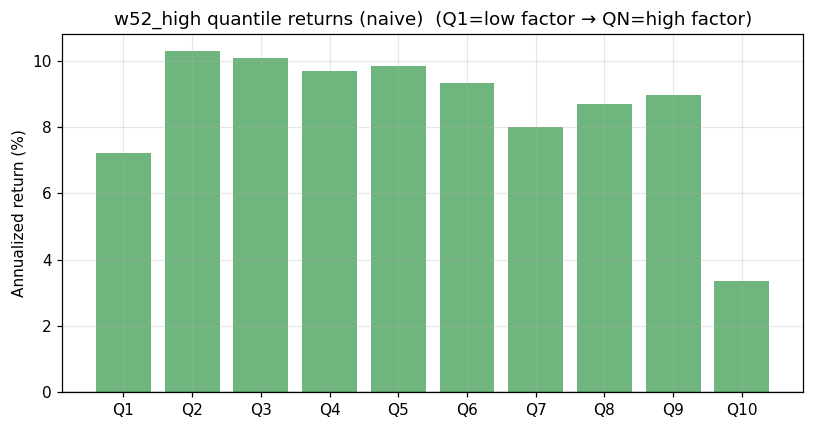

In [3]:
w52_sn = preprocess.preprocess_factor(panel, behavioral.w52_high(panel), do_neutralize=True)
res = evaluate.evaluate_factor(panel, w52_sn, n_groups=10)
display(pd.Series(res["ic_summary"]).to_frame("值"))
print("多空(QN-Q1):", {k: round(v, 4) for k, v in res["quantile_summary"].loc["多空(QN-Q1)"].items()})
fig = plotting.plot_quantile_bars(res["quantile_summary"], title="w52_high quantile returns (naive)")
plt.show()

**结果**：IC≈−0.01、t≈−0.84、多空夏普为负，分层也不单调。
朴素结论是"52周高点在A股无效，甚至略反向"。**但先别下结论——它可能被别的因子搅了。**

## ③ 它是不是动量/反转的伪装？——相关性

"靠近52周高点"天然意味着"最近涨得多"。所以它必然和动量、反转纠缠。先看横截面相关。

,w52,mom,rev,size
w52,1.0000,0.3250,-0.4090,-0.1830
mom,0.3250,1.0000,0.0450,-0.1570
rev,-0.4090,0.0450,1.0000,0.0730
size,-0.1830,-0.1570,0.0730,1.0000


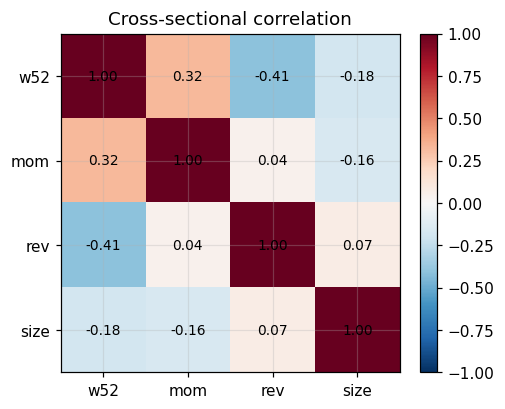

In [4]:
df = pd.DataFrame({"w52": w52.values, "mom": mom.values, "rev": rev.values,
                   "size": size.values, "dt": panel["trddt"].values}).dropna()
corr = (df.groupby("dt")[["w52", "mom", "rev", "size"]].corr()
        .groupby(level=1).mean().loc[["w52", "mom", "rev", "size"],
                                     ["w52", "mom", "rev", "size"]])
display(corr.round(3))
fig, ax = plt.subplots(figsize=(4.8, 4))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(4)); ax.set_xticklabels(corr.columns)
ax.set_yticks(range(4)); ax.set_yticklabels(corr.index)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=9)
ax.set_title("Cross-sectional correlation"); fig.colorbar(im, fraction=0.046)
plt.show()

**关键**：`w52` 与**动量 +0.33**、与**反转 −0.41** 高度相关。
A股反转极强，而"靠近高点=最近涨多=负反转信号"，反转把 w52 的收益往下拽——
它的真实效力被**掩盖**了。下一步把这些干扰剥掉。

## ④ 正交化：剥离动量/反转/市值，看"纯锚定"信号

把 w52 对 {动量, 反转, 市值} 做横截面回归，取**残差**——残差就是 w52 里
这三者解释不了的独立成分。若残差仍有显著 IC，说明锚定效应是真实且独立的。

,值
IC均值,0.0324
IC标准差,0.1276
ICIR,0.2540
t值,2.9000
IC>0占比,0.6560
|IC|>0.02占比,0.8930
期数,131.0000


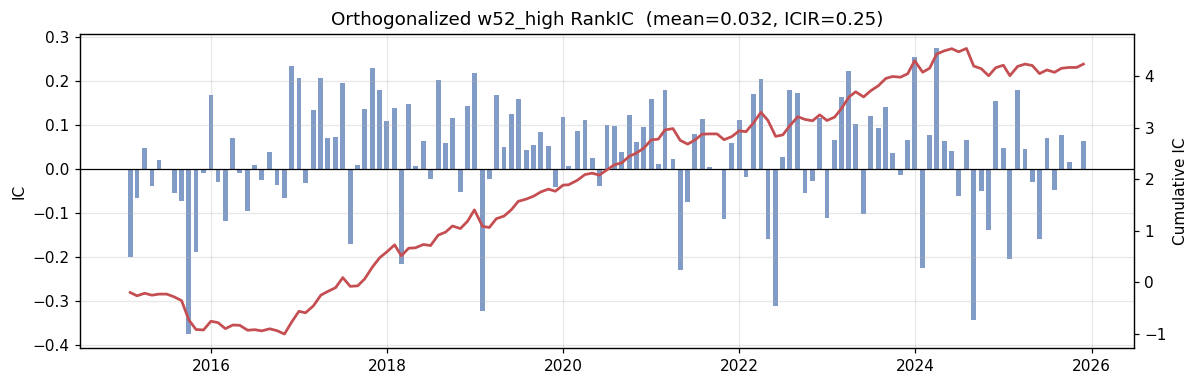

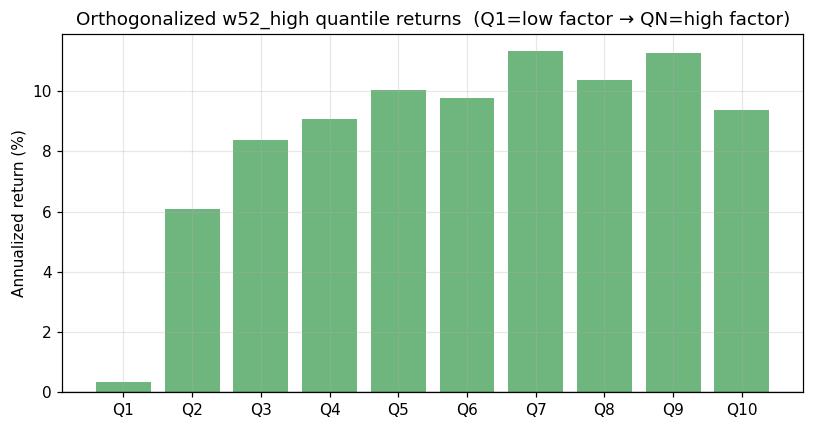

In [5]:
resid = preprocess.orthogonalize(panel, w52, {"mom": mom, "rev": rev, "size": size})
ic_resid = evaluate.compute_ic(panel, resid)
display(pd.Series(evaluate.ic_summary(ic_resid)).to_frame("值"))
fig = plotting.plot_ic_series(ic_resid, title="Orthogonalized w52_high RankIC"); plt.show()
qsum = evaluate.quantile_summary(evaluate.quantile_returns(panel, resid, 10))
fig = plotting.plot_quantile_bars(qsum, title="Orthogonalized w52_high quantile returns"); plt.show()

**发现**：残差 IC **翻正且显著（IC≈+0.032，t≈2.9）**，分层也变单调。
→ **锚定效应在A股确实存在，之前只是被强烈的反转效应掩盖了。**
纯粹的"锚定"成分携带独立、显著的 alpha。

## ⑤ Fama-MacBeth 多元回归：控制一切后的边际贡献

逐期把未来收益对 4 个因子一起回归，看各自的独立预测力（|t|>2 即显著）。

In [6]:
fm = evaluate.fama_macbeth(panel, {"w52": w52, "mom": mom, "rev": rev, "size": size})
fm

,coef均值,t值,系数为正占比,期数
const,0.0101,1.4600,0.5270,131
w52,0.0021,1.5100,0.6180,131
mom,-0.0008,-0.5800,0.4730,131
rev,0.0050,3.7500,0.6410,131
size,0.0047,3.0900,0.6260,131


## ⑥ 结论（诚实、有层次）

- **朴素地看**，52周高点因子在A股无效（t≈−0.84）——与"动量在A股失效"一致。
- **但这是假象**：它与动量(+0.33)、反转(−0.41)高度纠缠，效力被反转掩盖。
- **正交化后**，纯锚定信号 IC 翻正且显著（t≈2.9）——**锚定效应在A股真实存在且独立**。
- **Fama-MacBeth** 中其边际 t≈1.5（正但温和），反转(t≈3.8)与市值(t≈3.1)主导横截面。
- **完整结论**：52周高点作为单独可交易因子在A股偏弱；但作为**正交化的独立成分**，
  它贡献了显著、与众不同的增量 alpha。这正是它在多因子合成(L3)中的价值所在。

> 方法论要点：一个因子"看起来无效"，可能只是被其它因子掩盖。**相关性 + 正交化 +
> Fama-MacBeth** 三件套，才能分清"真无效"与"被掩盖"。下一步 L3 会把这个正交化的
> 52周高点信号，和经典因子一起用 ML 合成。